In [4]:
# instalação das bibliotecas necessárias caso não estejam presentes

!pip install -q seaborn scikit-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# configuração visual padrão para todos os gráficos do notebook
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# carrega o dataset a partir da pasta data/

df = pd.read_csv('../data/job_salary_prediction_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (250000, 10)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [6]:
# verificação inicial da qualidade dos dados: tipos, nulos e duplicatas

print('=== dtypes ===')
print(df.dtypes)
print('\n=== Valores nulos ===')
print(df.isnull().sum())
print('\n=== Duplicatas ===')
print(f'{df.duplicated().sum()} linhas duplicadas')

=== dtypes ===
job_title             str
experience_years    int64
education_level       str
skills_count        int64
industry              str
company_size          str
location              str
remote_work           str
certifications      int64
salary              int64
dtype: object

=== Valores nulos ===
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

=== Duplicatas ===
0 linhas duplicadas


In [7]:
# estatísticas descritivas das variáveis numéricas (média, desvio, percentis)

df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [8]:
# contagem de registros por categoria para verificar balanceamento das variáveis categóricas

cat_cols = ['job_title','education_level','industry','company_size','location','remote_work']
for col in cat_cols:
    vals = df[col].value_counts()
    print(f'\n[{col}] — {df[col].nunique()} categorias')
    print(vals.to_string())


[job_title] — 12 categorias
job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633

[education_level] — 5 categorias
education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776

[industry] — 10 categorias
industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841

[company_size] — 5 categorias
company_size
Large         50254
Small         50235
Medium        50027
Enterprise    4

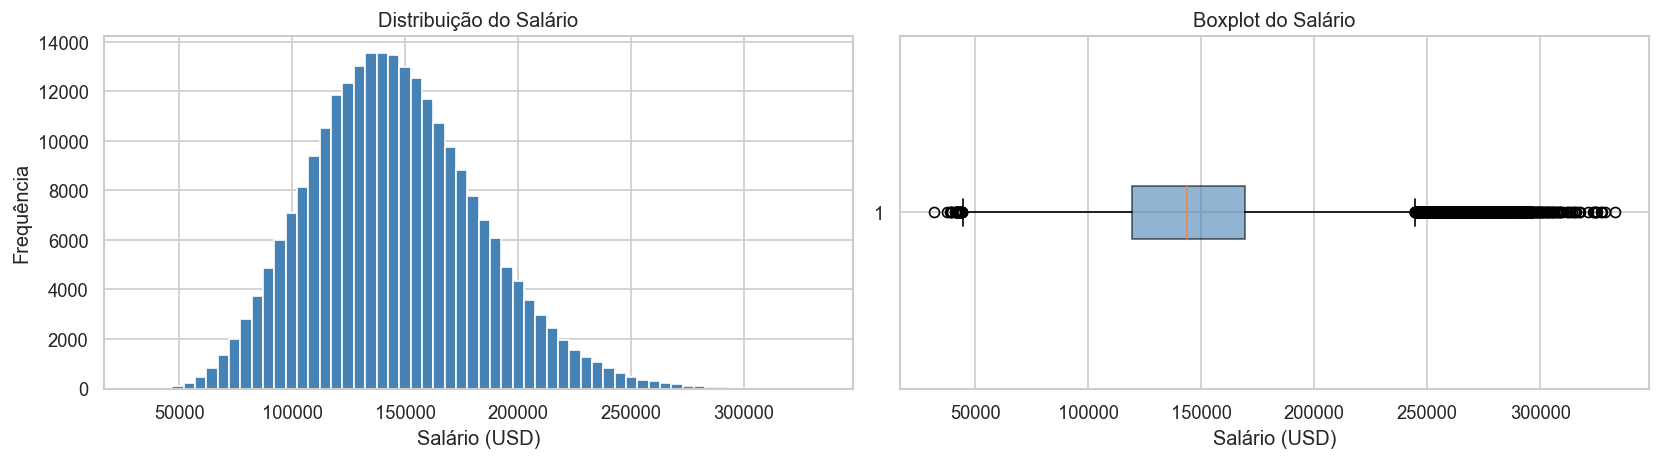

Média: $145,718
Mediana: $143,453
Desvio-padrão: $37,408
Skewness: 0.379


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))


# distribuição do salário: histograma para ver a forma e boxplot para identificar outliers

axes[0].hist(df['salary'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Salário')
axes[0].set_xlabel('Salário (USD)')
axes[0].set_ylabel('Frequência')

# Boxplot
axes[1].boxplot(df['salary'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot do Salário')
axes[1].set_xlabel('Salário (USD)')

plt.tight_layout()

plt.savefig('../results/distribuicao_salario.png', dpi=120, bbox_inches='tight')

plt.show()

print(f'Média: ${df["salary"].mean():,.0f}')
print(f'Mediana: ${df["salary"].median():,.0f}')
print(f'Desvio-padrão: ${df["salary"].std():,.0f}')
print(f'Skewness: {df["salary"].skew():.3f}')



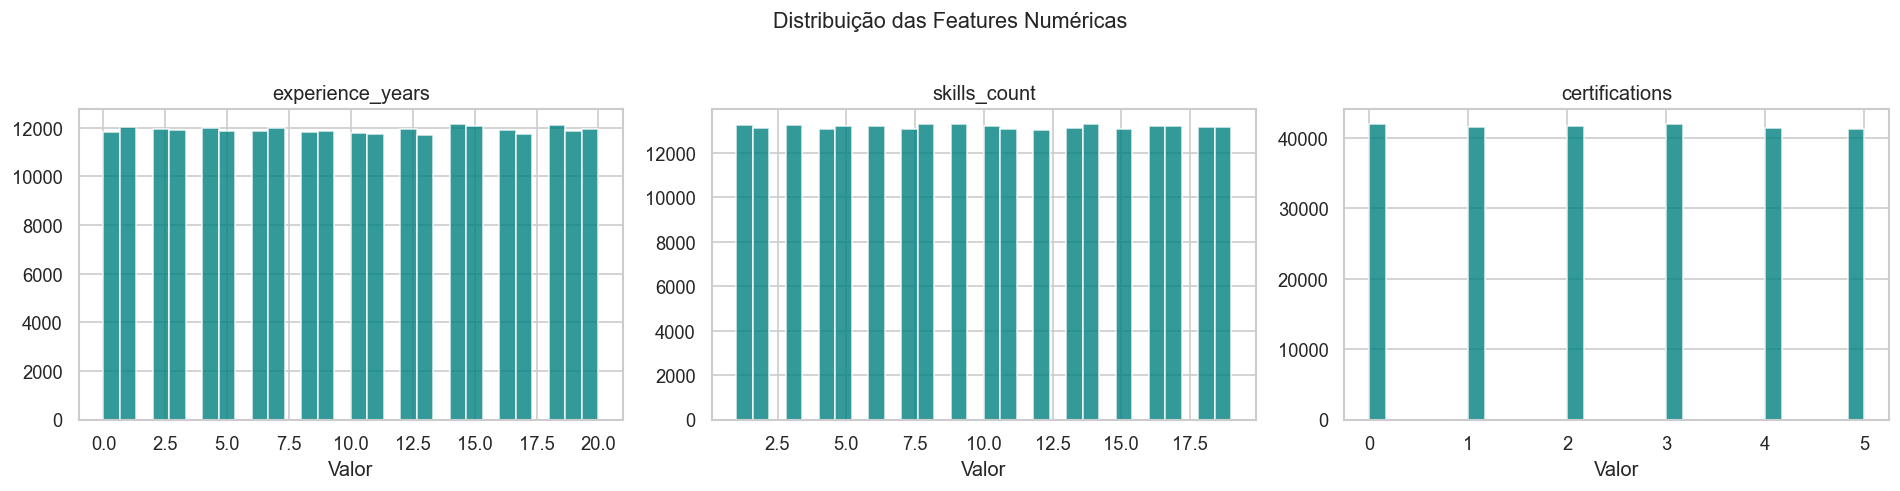

In [10]:
num_cols = ['experience_years', 'skills_count', 'certifications']


# distribuição das features numéricas: experiência, skills e certificações
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=30, color='teal', edgecolor='white', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('Valor')
plt.suptitle('Distribuição das Features Numéricas', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

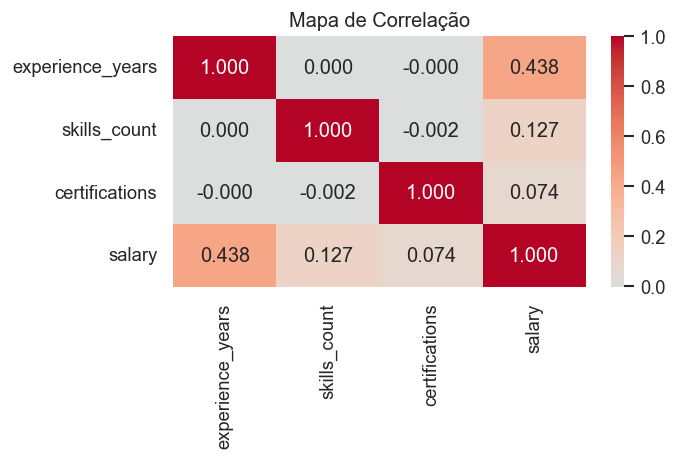

In [11]:
corr_df = df[num_cols + ['salary']].corr()
plt.figure(figsize=(6, 4))


# correlação entre as variáveis numéricas para identificar relações lineares com o salário

sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Mapa de Correlação')
plt.tight_layout()

plt.savefig('../results/salario_por_categorias.png', dpi=120, bbox_inches='tight')

plt.show()

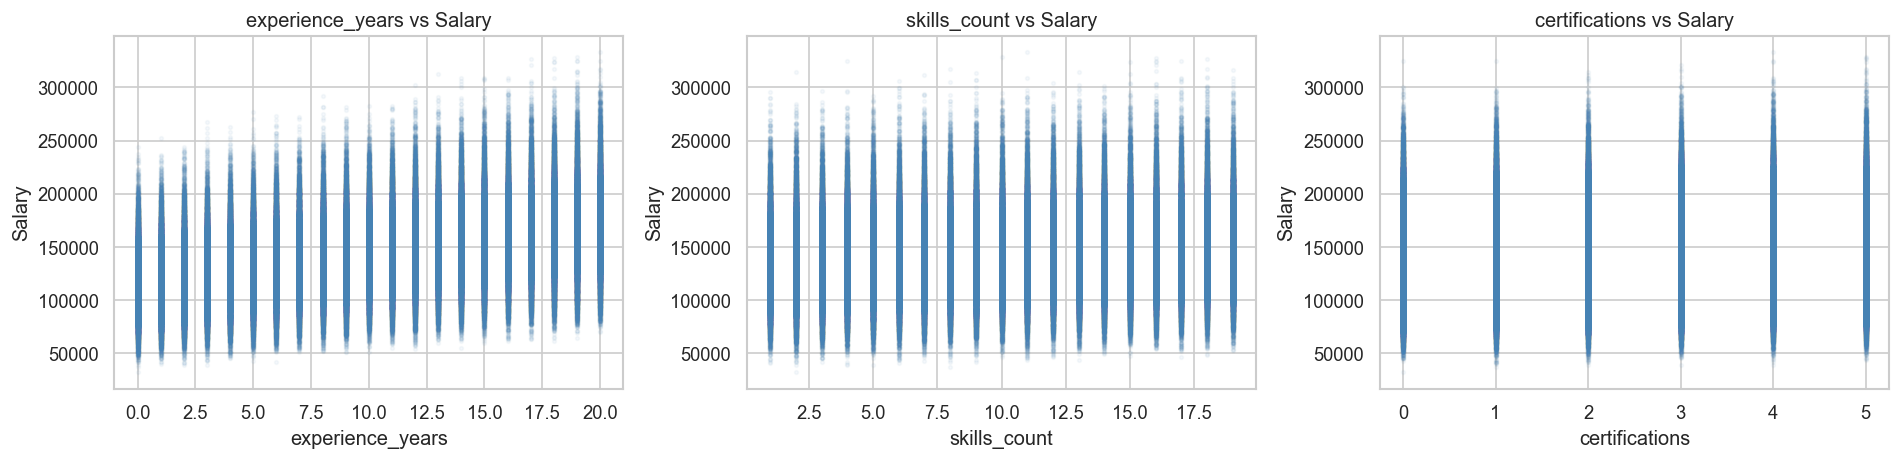

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    
    # scatter plots para visualizar a relação individual de cada feature numérica com o salário
    
    ax.scatter(df[col], df['salary'], alpha=0.05, s=5, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Salary')
    ax.set_title(f'{col} vs Salary')
plt.tight_layout()
plt.show()

C:\Users\renna\AppData\Local\Temp\ipykernel_6124\1353637689.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='salary', order=order, ax=axes[i], palette='muted')
C:\Users\renna\AppData\Local\Temp\ipykernel_6124\1353637689.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='salary', order=order, ax=axes[i], palette='muted')
C:\Users\renna\AppData\Local\Temp\ipykernel_6124\1353637689.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='salary', order=order, ax=axes[i], palette='muted')
C

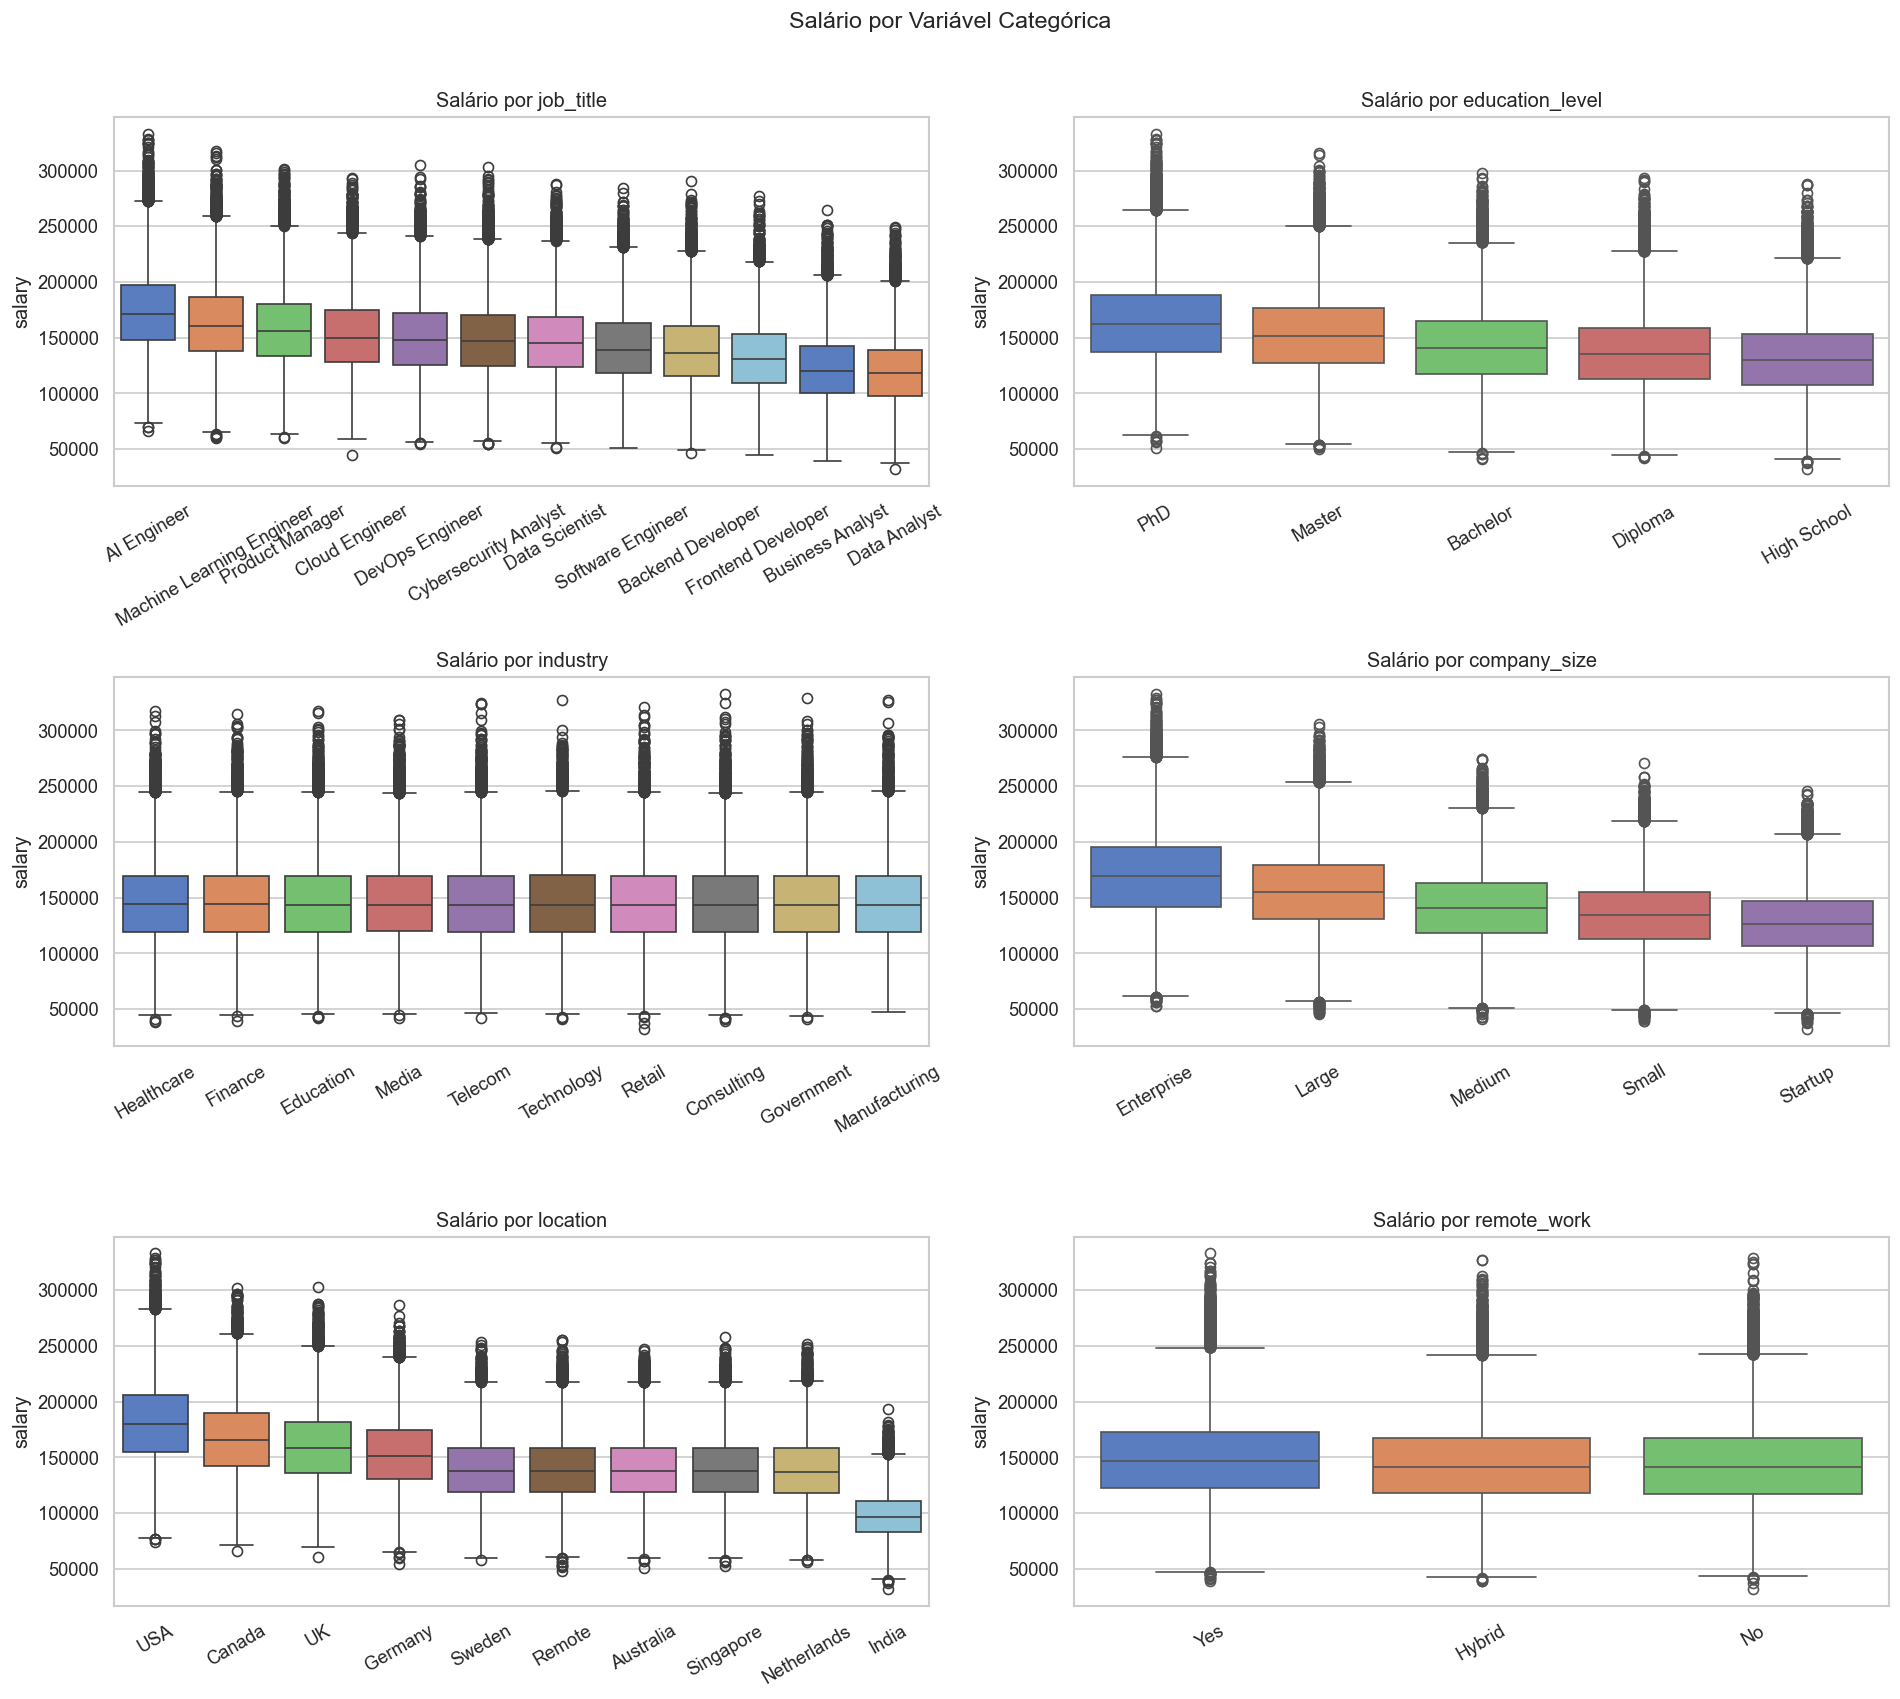

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df.groupby(col)['salary'].median().sort_values(ascending=False).index
    
    # boxplots das variáveis categóricas para comparar a distribuição salarial entre grupos
    sns.boxplot(data=df, x=col, y='salary', order=order, ax=axes[i], palette='muted')
    axes[i].set_title(f'Salário por {col}')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')

plt.suptitle('Salário por Variável Categórica', fontsize=14, y=1.01)
plt.tight_layout()

plt.savefig('../results/correlacao.png', dpi=120, bbox_inches='tight')

plt.show()

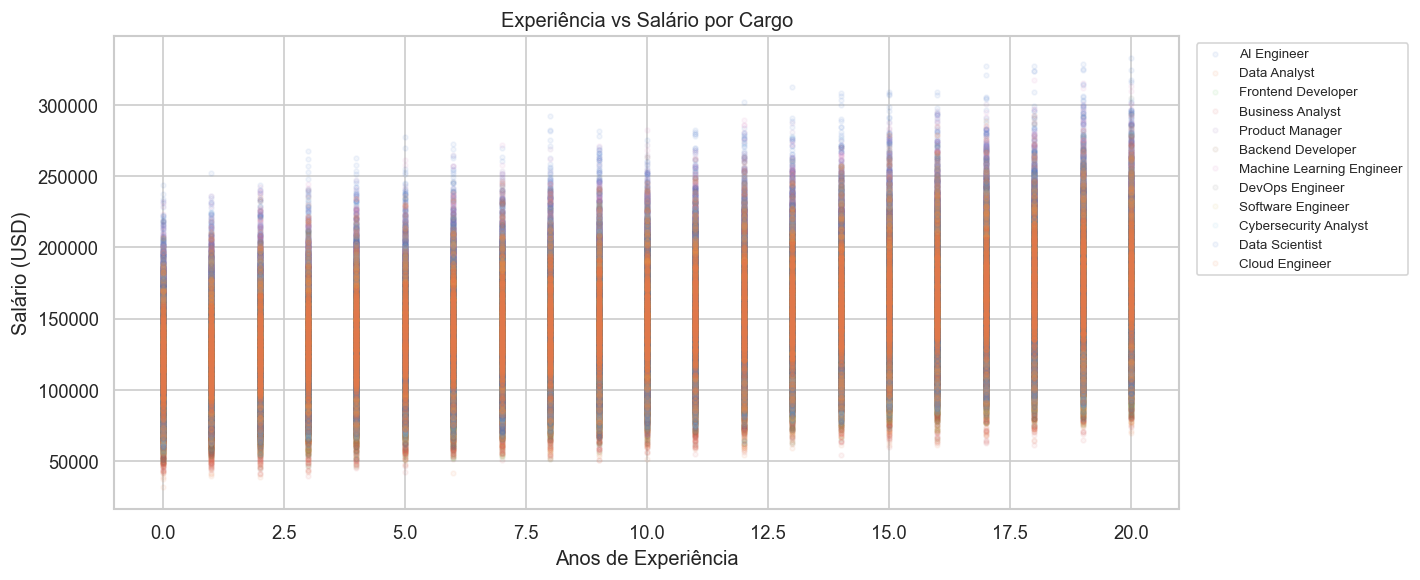

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

# relação entre experiência e salário separada por cargo
for jt in df['job_title'].unique():
    sub = df[df['job_title'] == jt]
    ax.scatter(sub['experience_years'], sub['salary'], alpha=0.07, s=8, label=jt)
ax.set_xlabel('Anos de Experiência')
ax.set_ylabel('Salário (USD)')
ax.set_title('Experiência vs Salário por Cargo')
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

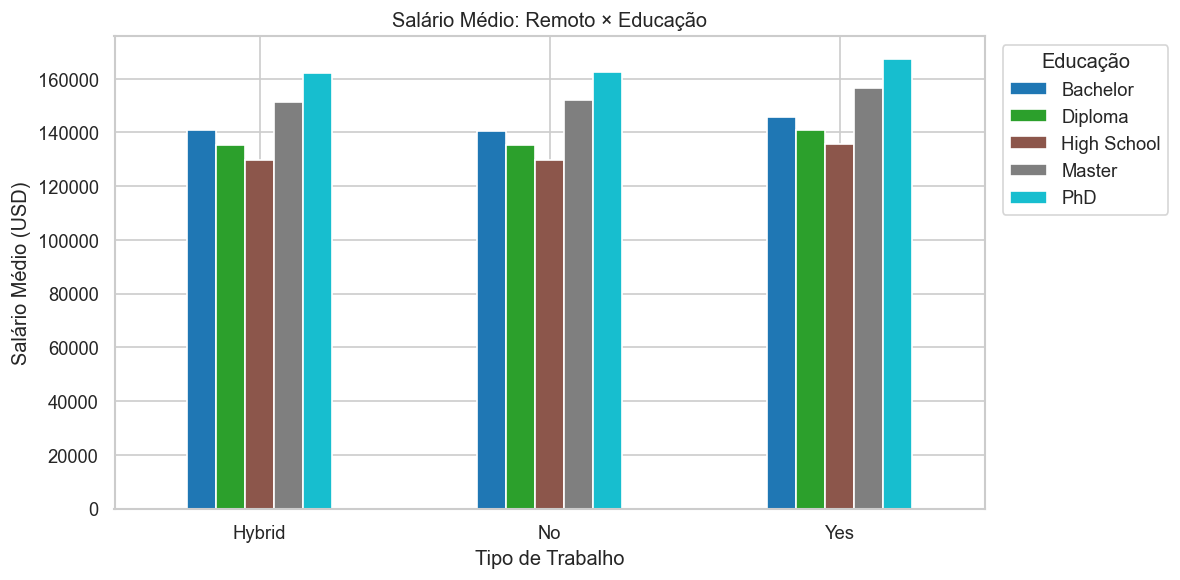

In [15]:
# interação entre modalidade de trabalho e nível de educação no salário médio

pivot = df.groupby(['remote_work', 'education_level'])['salary'].mean().unstack()
pivot.plot(kind='bar', figsize=(10, 5), colormap='tab10', edgecolor='white')
plt.title('Salário Médio: Remoto × Educação')
plt.xlabel('Tipo de Trabalho')
plt.ylabel('Salário Médio (USD)')
plt.xticks(rotation=0)
plt.legend(title='Educação', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

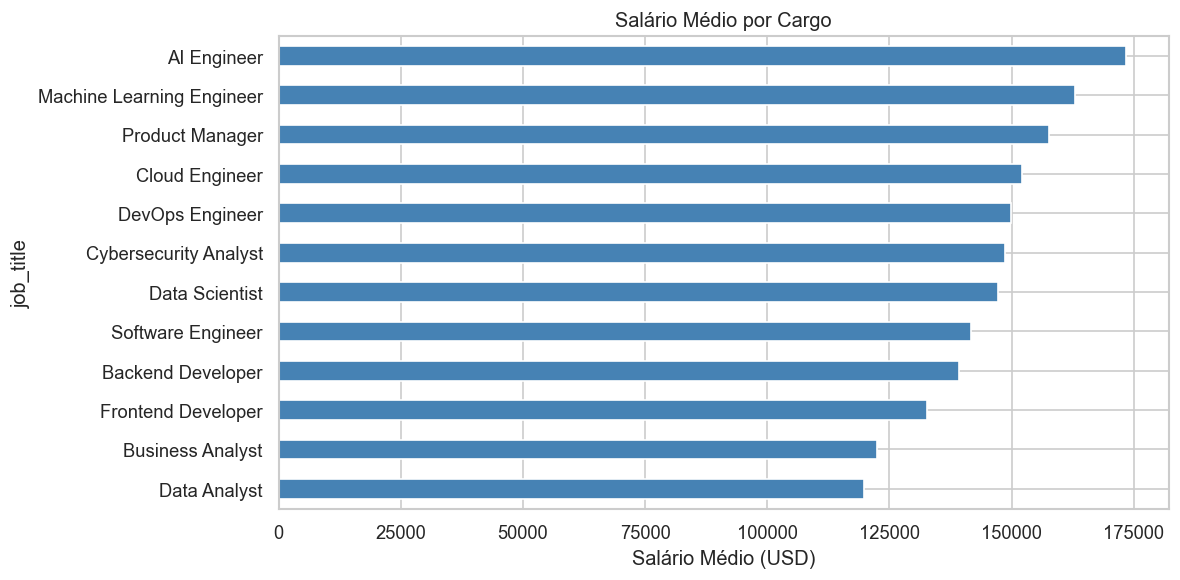

In [16]:
# ranking de salário médio por cargo

job_salary = df.groupby('job_title')['salary'].mean().sort_values(ascending=True)
plt.figure(figsize=(10, 5))
job_salary.plot(kind='barh', color='steelblue')
plt.title('Salário Médio por Cargo')
plt.xlabel('Salário Médio (USD)')
plt.tight_layout()
plt.show()

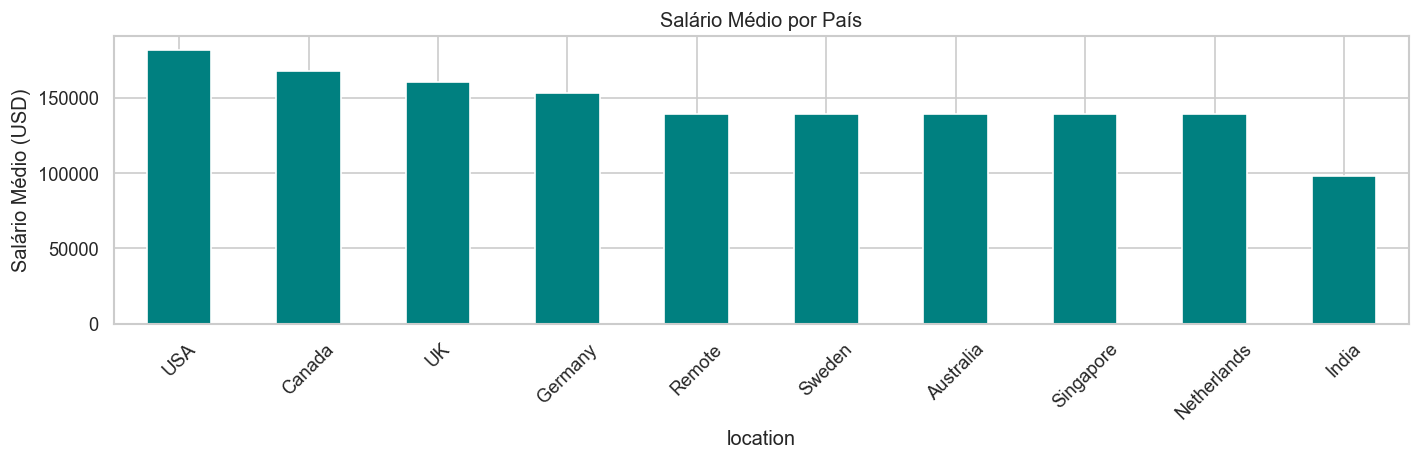

In [17]:
# comparação de salário médio entre países/regiões

loc_salary = df.groupby('location')['salary'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 4))
loc_salary.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Salário Médio por País')
plt.xticks(rotation=45)
plt.ylabel('Salário Médio (USD)')
plt.tight_layout()
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

# pré-processamento: copia o dataframe original e aplica label encoding nas variáveis categóricas
# label encoding converte texto em números para que os modelos de ml consigam processar

df_ml = df.copy()
le = LabelEncoder()

for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print('Dataset pronto para ML:')
df_ml.head()

Dataset pronto para ML:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,0,10,0,2,4,2,3,0,2,109413
1,5,5,0,17,9,3,0,1,0,93764
2,8,18,4,4,6,2,6,1,1,148123
3,2,19,4,13,7,2,1,2,0,189123
4,10,15,0,7,5,1,7,2,0,165069


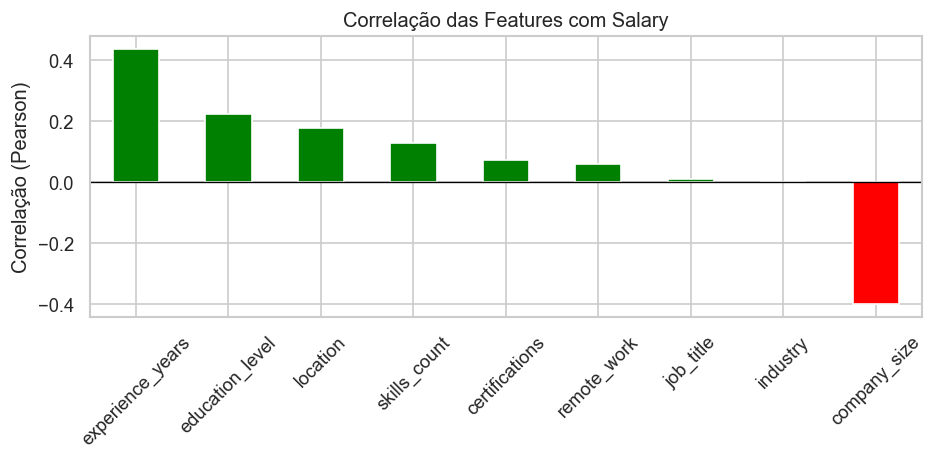

In [19]:
# correlação de todas as features com o salário após o encoding

correlations = df_ml.corr()['salary'].drop('salary').sort_values(ascending=False)
plt.figure(figsize=(8, 4))
correlations.plot(kind='bar', color=['green' if v > 0 else 'red' for v in correlations])
plt.title('Correlação das Features com Salary')
plt.ylabel('Correlação (Pearson)')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Com base na EDA, os modelos escolhidos são:

| Técnica | Justificativa |
|---|---|
| **Regressão Linear** | Baseline simples; boa para interpretar impacto de cada feature |
| **Random Forest Regressor** | Captura não-linearidades; robusto a outliers |
| **XGBoost Regressor** | Alta performance em dados tabulares estruturados |

**Métricas de avaliação:**
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² Score

**Divisão sugerida:** 80% treino / 20% teste com `random_state=42`

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df_ml.drop(columns='salary')
y = df_ml['salary']


# separação entre features (X) e target (y), depois divisão treino/teste 80/20

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (200000, 9) | Teste: (50000, 9)


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
# pip install xgboost se necessário
from xgboost import XGBRegressor


# definição e treinamento dos três modelos; avaliação com rmse, mae e r² no conjunto de teste

models = {
    'Regressão Linear': LinearRegression(),
    'Random Forest':    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':          XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    results.append({'Modelo': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2})
    print(f'{name:25s} | RMSE: {rmse:,.0f} | MAE: {mae:,.0f} | R²: {r2:.4f}')

results_df = pd.DataFrame(results)

Regressão Linear          | RMSE: 27,498 | MAE: 21,741 | R²: 0.4560
Random Forest             | RMSE: 6,557 | MAE: 5,184 | R²: 0.9691
XGBoost                   | RMSE: 5,568 | MAE: 4,439 | R²: 0.9777


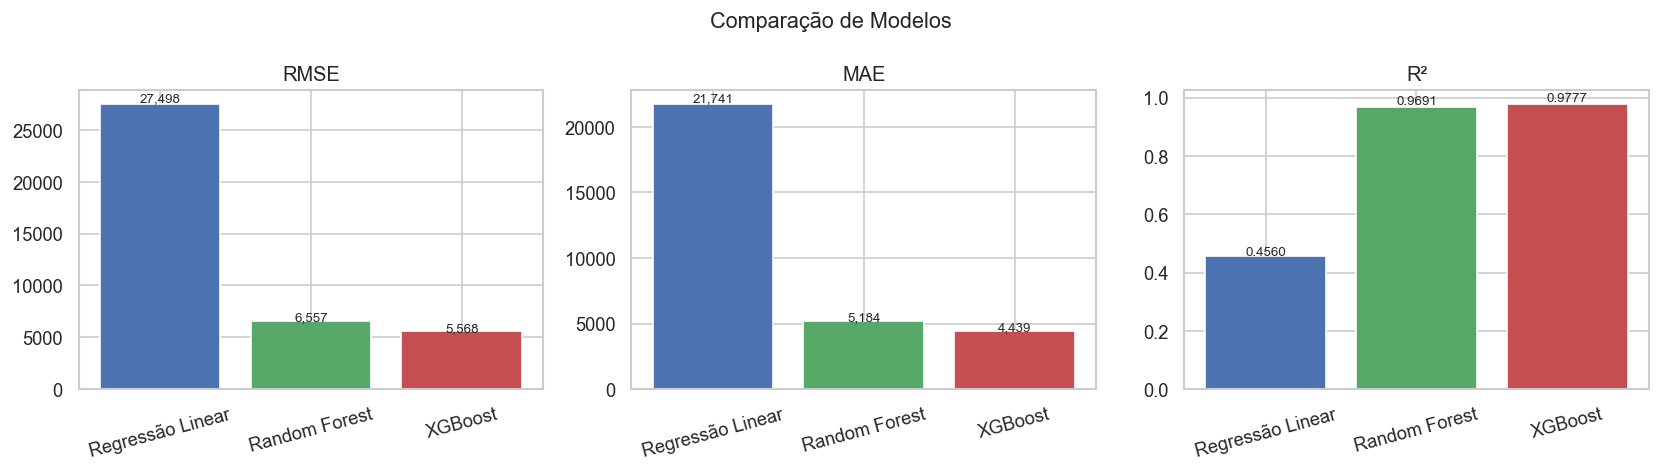

In [22]:
# gráfico comparativo das métricas dos três modelos

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    bars = ax.bar(results_df['Modelo'], results_df[metric],
                  color=['#4c72b0','#55a868','#c44e52'])
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:,.0f}' if metric != 'R²' else f'{val:.4f}',
                ha='center', fontsize=8)
plt.suptitle('Comparação de Modelos', fontsize=13)
plt.tight_layout()

plt.savefig('../results/comparacao_modelos.png', dpi=120, bbox_inches='tight')

plt.show()

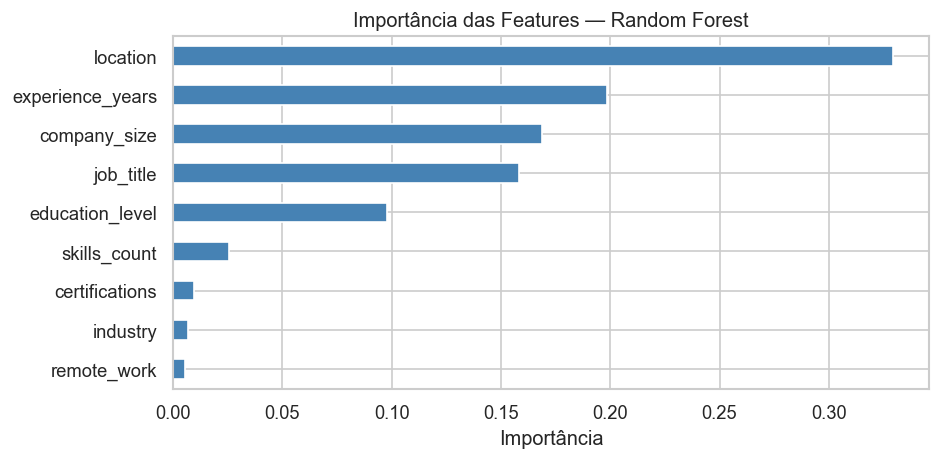

In [23]:
# importância de cada feature segundo o random forest: indica quais variáveis mais influenciam o salário

rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Importância das Features — Random Forest')
plt.xlabel('Importância')
plt.tight_layout()

plt.savefig('../results/feature_importance.png', dpi=120, bbox_inches='tight')

plt.show()